In [ ]:
import scipy.io as sio
import numpy as np
import pandas as pd
import glob
import os
import re
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, hilbert
from scipy.fft import fft, fftfreq

def load_mat_file(filepath, default_rpm=1772):
    data = sio.loadmat(filepath)
    de_key = [k for k in data if 'DE_time' in k][0]
    rpm_keys = [k for k in data if 'RPM' in k]
    signal = data[de_key].flatten()
    if rpm_keys:
        rpm = int(data[rpm_keys[0]][0, 0])
    else:
        rpm = default_rpm 
    return signal, rpm

def parse_label(filename):
    name = os.path.basename(filename).replace(".mat", "")
    if "Normal" in name:
        return "Normal", None
    match = re.match(r"([A-Za-z]+)(\d+)", name)
    if match:
        return match.group(1), match.group(2)
    return "Unknown", None

In [4]:
data_dir = "../data/raw/cwru"
mat_files = glob.glob(os.path.join(data_dir, "*.mat"))

summary = []
for f in mat_files:
    signal, rpm = load_mat_file(f)
    fault_type, severity = parse_label(f)
    summary.append({
        "file": os.path.basename(f),
        "fault_type": fault_type,
        "severity": severity,
        "rpm": rpm,
        "n_samples": len(signal),
        "duration_sec": len(signal) / 48000
    })

summary_df = pd.DataFrame(summary)
print(summary_df)

                     file fault_type severity   rpm  n_samples  duration_sec
0              B007_0.mat          B      007  1796     122571      2.553562
1          B007_1_123.mat          B      007  1772     487384     10.153833
2              B007_2.mat          B      007  1748     121556      2.532417
3              B007_3.mat          B      007  1722     121556      2.532417
4              B014_0.mat          B      014  1796     121846      2.538458
5          B014_1_190.mat          B      014  1772     486224     10.129667
6              B014_2.mat          B      014  1749     121991      2.541479
7              B014_3.mat          B      014  1724     122136      2.544500
8              B021_0.mat          B      021  1796     121991      2.541479
9          B021_1_227.mat          B      021  1774     486804     10.141750
10             B021_2.mat          B      021  1754     122136      2.544500
11             B021_3.mat          B      021  1729     122136      2.544500

In [5]:
def compute_bearing_frequencies(rpm, n_balls=9, d=7.938, D=38.5, theta=0):
    fr = rpm / 60
    ratio = (d / D) * np.cos(np.radians(theta))
    BPFO = (n_balls / 2) * fr * (1 - ratio)
    BPFI = (n_balls / 2) * fr * (1 + ratio)
    BSF  = (D / (2 * d)) * fr * (1 - ratio**2)
    FTF  = (fr / 2) * (1 - ratio)
    return {"BPFO": BPFO, "BPFI": BPFI, "BSF": BSF, "FTF": FTF, "fr": fr}

def envelope_spectrum(signal, fs=48000, band=(2500, 3500)):
    nyq = fs / 2
    b, a = butter(4, [band[0]/nyq, band[1]/nyq], btype='band')
    filtered = filtfilt(b, a, signal)
    envelope = np.abs(hilbert(filtered))
    envelope = envelope - envelope.mean()
    n = len(envelope)
    yf = np.abs(fft(envelope))[:n // 2] / n
    xf = fftfreq(n, 1/fs)[:n // 2]
    return xf, yf

def energy_near_frequency(xf, yf, target_freq, window=3):
    mask = (xf > target_freq - window) & (xf < target_freq + window)
    if not mask.any():
        return 0.0
    return yf[mask].max()

In [6]:
signal, rpm = load_mat_file("../data/raw/cwru/B007_1_123.mat")
freqs = compute_bearing_frequencies(rpm)
xf, yf = envelope_spectrum(signal)

for name in ["BPFO", "BPFI", "BSF"]:
    for harmonic in [1, 2, 3]:
        target = freqs[name] * harmonic
        amp = energy_near_frequency(xf, yf, target)
        print(f"{name} x{harmonic} ({target:.1f} Hz): {amp:.6f}")

BPFO x1 (105.5 Hz): 0.003396
BPFO x2 (211.0 Hz): 0.004748
BPFO x3 (316.5 Hz): 0.003035
BPFI x1 (160.3 Hz): 0.002349
BPFI x2 (320.6 Hz): 0.003035
BPFI x3 (480.9 Hz): 0.002098
BSF x1 (68.6 Hz): 0.003038
BSF x2 (137.2 Hz): 0.002465
BSF x3 (205.7 Hz): 0.001837


In [7]:
data_normal = sio.loadmat("../data/raw/cwru/Time_Normal_1_098.mat")
print([k for k in data_normal.keys() if not k.startswith("__")])

['X098_DE_time', 'X098_FE_time']


In [8]:
def extract_window_features(window, rpm, fs=48000):
    """One window of raw signal -> one row of frequency-domain features."""
    freqs = compute_bearing_frequencies(rpm)
    xf, yf = envelope_spectrum(window, fs=fs)

    features = {}
    for name in ["BPFO", "BPFI", "BSF"]:
        for harmonic in [1, 2, 3]:
            target = freqs[name] * harmonic
            features[f"{name}_x{harmonic}"] = energy_near_frequency(xf, yf, target)

    # A couple of simple time-domain stats too, cheap to add, often genuinely useful alongside frequency features
    features["rms"] = np.sqrt(np.mean(window**2))
    features["kurtosis"] = pd.Series(window).kurtosis()

    return features

def process_file(filepath, window_size=2048):
    signal, rpm = load_mat_file(filepath)
    fault_type, severity = parse_label(filepath)

    n_windows = len(signal) // window_size
    rows = []
    for i in range(n_windows):
        window = signal[i*window_size : (i+1)*window_size]
        feats = extract_window_features(window, rpm)
        feats["fault_type"] = fault_type
        feats["severity"] = severity
        feats["source_file"] = os.path.basename(filepath)
        rows.append(feats)
    return rows

all_rows = []
for f in mat_files:
    all_rows.extend(process_file(f))

bearing_df = pd.DataFrame(all_rows)
print(bearing_df.shape)
print(bearing_df["fault_type"].value_counts())
print(bearing_df.head())

(4791, 14)
fault_type
IR        1243
B         1242
OR        1242
Normal    1064
Name: count, dtype: int64
   BPFO_x1   BPFO_x2  BPFO_x3   BPFI_x1  BPFI_x2  BPFI_x3    BSF_x1    BSF_x2  \
0      0.0  0.001614      0.0  0.002099      0.0      0.0  0.001393  0.001393   
1      0.0  0.000565      0.0  0.002182      0.0      0.0  0.001862  0.001414   
2      0.0  0.000636      0.0  0.001694      0.0      0.0  0.000745  0.000652   
3      0.0  0.000207      0.0  0.001338      0.0      0.0  0.001318  0.001604   
4      0.0  0.000452      0.0  0.002118      0.0      0.0  0.001156  0.003104   

     BSF_x3       rms  kurtosis fault_type severity source_file  
0  0.001614  0.134602 -0.098028          B      007  B007_0.mat  
1  0.000565  0.139796  0.078723          B      007  B007_0.mat  
2  0.000636  0.133587 -0.397205          B      007  B007_0.mat  
3  0.000207  0.140045  0.097466          B      007  B007_0.mat  
4  0.000452  0.141407 -0.135187          B      007  B007_0.mat  


In [ ]:
def energy_near_frequency(xf, yf, target_freq, window=10):  # comfortably wider than the 5.86Hz bin spacing
    mask = (xf > target_freq - window) & (xf < target_freq + window)
    if not mask.any():
        return 0.0
    return yf[mask].max()

def process_file(filepath, window_size=8192):
    signal, rpm = load_mat_file(filepath)
    fault_type, severity = parse_label(filepath)

    n_windows = len(signal) // window_size
    rows = []
    for i in range(n_windows):
        window = signal[i*window_size : (i+1)*window_size]
        feats = extract_window_features(window, rpm)
        feats["fault_type"] = fault_type
        feats["severity"] = severity
        feats["source_file"] = os.path.basename(filepath)
        rows.append(feats)
    return rows

all_rows = []
for f in mat_files:
    all_rows.extend(process_file(f))

bearing_df = pd.DataFrame(all_rows)
print(bearing_df.shape)
print(bearing_df["fault_type"].value_counts())
print(bearing_df.head())

(1175, 14)
fault_type
IR        304
B         303
OR        303
Normal    265
Name: count, dtype: int64
    BPFO_x1   BPFO_x2   BPFO_x3   BPFI_x1   BPFI_x2   BPFI_x3    BSF_x1  \
0  0.000941  0.000237  0.000396  0.000942  0.000396  0.000266  0.000775   
1  0.001465  0.000597  0.000405  0.002027  0.000405  0.000379  0.000722   
2  0.001305  0.000952  0.000446  0.001509  0.000446  0.001442  0.001071   
3  0.001083  0.000492  0.000320  0.001208  0.000320  0.000679  0.000755   
4  0.000778  0.000387  0.000421  0.001370  0.000421  0.000328  0.000627   

     BSF_x2    BSF_x3       rms  kurtosis fault_type severity source_file  
0  0.000677  0.000382  0.137039 -0.060439          B      007  B007_0.mat  
1  0.001426  0.000597  0.139710 -0.004205          B      007  B007_0.mat  
2  0.000770  0.000438  0.135713 -0.059301          B      007  B007_0.mat  
3  0.000826  0.000492  0.140845 -0.057468          B      007  B007_0.mat  
4  0.000633  0.000387  0.138737 -0.002783          B      007  B0

In [10]:
freq_cols = [c for c in bearing_df.columns if any(x in c for x in ["BPFO", "BPFI", "BSF"])]
zero_fraction = (bearing_df[freq_cols] == 0.0).mean()
print(zero_fraction)

BPFO_x1    0.0
BPFO_x2    0.0
BPFO_x3    0.0
BPFI_x1    0.0
BPFI_x2    0.0
BPFI_x3    0.0
BSF_x1     0.0
BSF_x2     0.0
BSF_x3     0.0
dtype: float64


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

feature_cols_bearing = [c for c in bearing_df.columns if c not in ["fault_type", "severity", "source_file"]]

X = bearing_df[feature_cols_bearing]
y = bearing_df["fault_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify keeps class balance consistent in both sets
)

clf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
clf.fit(X_train, y_train)

preds = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print()
print(classification_report(y_test, preds))
print()
print("Confusion matrix (rows=true, cols=predicted):")
print(pd.DataFrame(confusion_matrix(y_test, preds), index=clf.classes_, columns=clf.classes_))

Accuracy: 0.948936170212766

              precision    recall  f1-score   support

           B       0.90      0.92      0.91        61
          IR       0.97      1.00      0.98        61
      Normal       1.00      1.00      1.00        53
          OR       0.93      0.88      0.91        60

    accuracy                           0.95       235
   macro avg       0.95      0.95      0.95       235
weighted avg       0.95      0.95      0.95       235


Confusion matrix (rows=true, cols=predicted):
         B  IR  Normal  OR
B       56   1       0   4
IR       0  61       0   0
Normal   0   0      53   0
OR       6   1       0  53


In [12]:
importances_bearing = pd.DataFrame({
    "feature": feature_cols_bearing,
    "importance": clf.feature_importances_
}).sort_values("importance", ascending=False)

print(importances_bearing)

     feature  importance
9        rms    0.395032
10  kurtosis    0.149640
1    BPFO_x2    0.079332
8     BSF_x3    0.068050
3    BPFI_x1    0.057639
0    BPFO_x1    0.053824
5    BPFI_x3    0.050949
7     BSF_x2    0.049741
2    BPFO_x3    0.033984
4    BPFI_x2    0.032474
6     BSF_x1    0.029335


In [13]:
# Get the actual misclassified rows
test_results = X_test.copy()
test_results["true_label"] = y_test.values
test_results["predicted"] = preds

confused = test_results[(test_results["true_label"] == "OR") & (test_results["predicted"] == "B")]
print(confused[["BPFO_x1", "BPFO_x2", "BSF_x1", "BSF_x2", "rms", "kurtosis"]])

# Compare against typical values for each true class
print("\nTypical OR values:")
print(test_results[test_results["true_label"]=="OR"][["BPFO_x1", "BSF_x1"]].describe())
print("\nTypical B values:")
print(test_results[test_results["true_label"]=="B"][["BPFO_x1", "BSF_x1"]].describe())

       BPFO_x1   BPFO_x2    BSF_x1    BSF_x2       rms  kurtosis
1004  0.009652  0.010944  0.008568  0.004952  0.138892  0.338593
921   0.000948  0.000452  0.001032  0.000488  0.100529 -0.120685
958   0.009128  0.006541  0.017189  0.005719  0.144158  0.278830
962   0.010528  0.010340  0.015994  0.006869  0.131453  0.295627
923   0.002027  0.000617  0.001407  0.000677  0.104139  0.174462
946   0.000950  0.000570  0.000893  0.001475  0.094907  0.354059

Typical OR values:
         BPFO_x1     BSF_x1
count  60.000000  60.000000
mean    0.108326   0.044038
std     0.153419   0.054836
min     0.000502   0.000787
25%     0.002267   0.002524
50%     0.007078   0.009609
75%     0.191010   0.075618
max     0.428343   0.162054

Typical B values:
         BPFO_x1     BSF_x1
count  61.000000  61.000000
mean    0.008146   0.009384
std     0.009710   0.010038
min     0.000430   0.000448
25%     0.001347   0.000995
50%     0.005700   0.007949
75%     0.011705   0.014081
max     0.058162   0.037258


In [ ]:
# Add window index and block grouping BEFORE splitting
def process_file(filepath, window_size=8192):
    signal, rpm = load_mat_file(filepath)
    fault_type, severity = parse_label(filepath)
    n_windows = len(signal) // window_size
    rows = []
    for i in range(n_windows):
        window = signal[i*window_size : (i+1)*window_size]
        feats = extract_window_features(window, rpm)
        feats["fault_type"] = fault_type
        feats["severity"] = severity
        feats["source_file"] = os.path.basename(filepath)
        feats["window_idx"] = i
        rows.append(feats)
    return rows

def extract_window_features_v2(window, rpm, fs=48000):
    freqs = compute_bearing_frequencies(rpm)
    xf, yf = envelope_spectrum(window, fs=fs)

    rms = np.sqrt(np.mean(window**2))

    features = {}
    for name in ["BPFO", "BPFI", "BSF"]:
        for harmonic in [1, 2, 3]:
            target = freqs[name] * harmonic
            raw_energy = energy_near_frequency(xf, yf, target)
            features[f"{name}_x{harmonic}_ratio"] = raw_energy / (rms + 1e-8)  # normalize by this window's own magnitude

    features["rms"] = rms
    features["kurtosis"] = pd.Series(window).kurtosis()
    return features

all_rows = []
for f in mat_files:
    all_rows.extend(process_file(f))

bearing_df = pd.DataFrame(all_rows)

# Group consecutive windows into blocks of 5 for voting
block_size = 5
bearing_df["block_id"] = bearing_df["source_file"] + "_" + (bearing_df["window_idx"] // block_size).astype(str)

# Split by BLOCK, not window, this keeps voting groups intact on one side
unique_blocks = bearing_df["block_id"].unique()
train_blocks, test_blocks = train_test_split(unique_blocks, test_size=0.2, random_state=42)

train_df_bearing = bearing_df[bearing_df["block_id"].isin(train_blocks)]
test_df_bearing = bearing_df[bearing_df["block_id"].isin(test_blocks)]

print(f"Train windows: {len(train_df_bearing)}, Test windows: {len(test_df_bearing)}")
print(f"Train blocks: {len(train_blocks)}, Test blocks: {len(test_blocks)}")

Train windows: 936, Test windows: 239
Train blocks: 194, Test blocks: 49


In [15]:
X_train_b = train_df_bearing[feature_cols_bearing]
y_train_b = train_df_bearing["fault_type"]
X_test_b = test_df_bearing[feature_cols_bearing]
y_test_b = test_df_bearing["fault_type"]

clf2 = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
clf2.fit(X_train_b, y_train_b)

# Per-window predictions, same as before
window_preds = clf2.predict(X_test_b)
window_accuracy = accuracy_score(y_test_b, window_preds)
print("Per-window accuracy (block-based split):", window_accuracy)

# Now the majority-vote step: group predictions by block, take the most common prediction per block
test_df_bearing = test_df_bearing.copy()
test_df_bearing["prediction"] = window_preds

block_votes = test_df_bearing.groupby("block_id").agg(
    true_label=("fault_type", "first"),          # all windows in a block share the same true label
    predicted=("prediction", lambda x: x.mode()[0])  # majority vote across the block's windows
)

block_accuracy = accuracy_score(block_votes["true_label"], block_votes["predicted"])
print("Per-block (majority vote) accuracy:", block_accuracy)

print("\nBlock-level confusion matrix:")
print(pd.DataFrame(
    confusion_matrix(block_votes["true_label"], block_votes["predicted"], labels=clf2.classes_),
    index=clf2.classes_, columns=clf2.classes_
))

Per-window accuracy (block-based split): 0.9581589958158996
Per-block (majority vote) accuracy: 0.9795918367346939

Block-level confusion matrix:
         B  IR  Normal  OR
B       14   0       0   0
IR       0  12       0   0
Normal   0   0      13   0
OR       1   0       0   9


In [16]:
from sklearn.metrics import accuracy_score

lofo_results = []
unique_files = bearing_df["source_file"].unique()

for held_out_file in unique_files:
    train_lofo = bearing_df[bearing_df["source_file"] != held_out_file]
    test_lofo = bearing_df[bearing_df["source_file"] == held_out_file]

    X_tr, y_tr = train_lofo[feature_cols_bearing], train_lofo["fault_type"]
    X_te, y_te = test_lofo[feature_cols_bearing], test_lofo["fault_type"]

    model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc = accuracy_score(y_te, preds)

    lofo_results.append({
        "held_out_file": held_out_file,
        "true_fault_type": test_lofo["fault_type"].iloc[0],
        "n_test_windows": len(test_lofo),
        "accuracy": acc
    })

lofo_df = pd.DataFrame(lofo_results)
print(lofo_df)
print(f"\nMean LOFO accuracy: {lofo_df['accuracy'].mean():.3f}")
print(f"Min LOFO accuracy: {lofo_df['accuracy'].min():.3f} (worst case — this is the honest number)")

            held_out_file true_fault_type  n_test_windows  accuracy
0              B007_0.mat               B              14  1.000000
1          B007_1_123.mat               B              59  0.118644
2              B007_2.mat               B              14  1.000000
3              B007_3.mat               B              14  1.000000
4              B014_0.mat               B              14  0.428571
5          B014_1_190.mat               B              59  0.881356
6              B014_2.mat               B              14  0.785714
7              B014_3.mat               B              14  0.928571
8              B021_0.mat               B              14  0.928571
9          B021_1_227.mat               B              59  0.881356
10             B021_2.mat               B              14  0.785714
11             B021_3.mat               B              14  1.000000
12            IR007_0.mat              IR              14  1.000000
13        IR007_1_110.mat              IR       

In [17]:
from sklearn.metrics import accuracy_score

lofo_results = []
unique_files = bearing_df["source_file"].unique()

for held_out_file in unique_files:
    train_lofo = bearing_df[bearing_df["source_file"] != held_out_file]
    test_lofo = bearing_df[bearing_df["source_file"] == held_out_file]

    X_tr, y_tr = train_lofo[feature_cols_bearing], train_lofo["fault_type"]
    X_te, y_te = test_lofo[feature_cols_bearing], test_lofo["fault_type"]

    model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc = accuracy_score(y_te, preds)

    lofo_results.append({
        "held_out_file": held_out_file,
        "true_fault_type": test_lofo["fault_type"].iloc[0],
        "n_test_windows": len(test_lofo),
        "accuracy": acc
    })

lofo_df = pd.DataFrame(lofo_results)
print(lofo_df)
print(f"\nMean LOFO accuracy: {lofo_df['accuracy'].mean():.3f}")
print(f"Min LOFO accuracy: {lofo_df['accuracy'].min():.3f} (worst case — this is the honest number)")

            held_out_file true_fault_type  n_test_windows  accuracy
0              B007_0.mat               B              14  1.000000
1          B007_1_123.mat               B              59  0.118644
2              B007_2.mat               B              14  1.000000
3              B007_3.mat               B              14  1.000000
4              B014_0.mat               B              14  0.428571
5          B014_1_190.mat               B              59  0.881356
6              B014_2.mat               B              14  0.785714
7              B014_3.mat               B              14  0.928571
8              B021_0.mat               B              14  0.928571
9          B021_1_227.mat               B              59  0.881356
10             B021_2.mat               B              14  0.785714
11             B021_3.mat               B              14  1.000000
12            IR007_0.mat              IR              14  1.000000
13        IR007_1_110.mat              IR       

In [18]:
for fault in ["B", "IR", "OR"]:
    print(f"\n--- {fault} ---")
    subset = bearing_df[bearing_df["fault_type"] == fault]
    print(subset.groupby("severity")[["BPFO_x1", "BSF_x1", "rms"]].mean())


--- B ---
           BPFO_x1    BSF_x1       rms
severity                              
007       0.005102  0.007775  0.143458
014       0.008350  0.009577  0.143149
021       0.010124  0.009275  0.169292

--- IR ---
           BPFO_x1    BSF_x1       rms
severity                              
007       0.017536  0.016354  0.288416
014       0.005260  0.010506  0.190494
021       0.028837  0.041515  0.557568

--- OR ---
           BPFO_x1    BSF_x1       rms
severity                              
007       0.238759  0.047733  0.871250
014       0.005136  0.006649  0.120446
021       0.112475  0.085398  0.597773


In [19]:
# --- Step 1: redefine feature extraction with RMS-normalized ratios ---
def extract_window_features_v2(window, rpm, fs=48000):
    freqs = compute_bearing_frequencies(rpm)
    xf, yf = envelope_spectrum(window, fs=fs)

    rms = np.sqrt(np.mean(window**2))

    features = {}
    for name in ["BPFO", "BPFI", "BSF"]:
        for harmonic in [1, 2, 3]:
            target = freqs[name] * harmonic
            raw_energy = energy_near_frequency(xf, yf, target)
            features[f"{name}_x{harmonic}_ratio"] = raw_energy / (rms + 1e-8)

    features["rms"] = rms
    features["kurtosis"] = pd.Series(window).kurtosis()
    return features

def process_file_v2(filepath, window_size=8192):
    signal, rpm = load_mat_file(filepath)
    fault_type, severity = parse_label(filepath)
    n_windows = len(signal) // window_size
    rows = []
    for i in range(n_windows):
        window = signal[i*window_size : (i+1)*window_size]
        feats = extract_window_features_v2(window, rpm)
        feats["fault_type"] = fault_type
        feats["severity"] = severity
        feats["source_file"] = os.path.basename(filepath)
        feats["window_idx"] = i
        rows.append(feats)
    return rows

# --- Step 2: rebuild the full feature table ---
all_rows_v2 = []
for f in mat_files:
    all_rows_v2.extend(process_file_v2(f))

bearing_df_v2 = pd.DataFrame(all_rows_v2)
feature_cols_v2 = [c for c in bearing_df_v2.columns if c not in ["fault_type", "severity", "source_file", "window_idx"]]

print(bearing_df_v2.shape)
print(bearing_df_v2.groupby(["fault_type", "severity"])[["BPFO_x1_ratio", "BSF_x1_ratio", "rms"]].mean())

# --- Step 3: re-run the SAME LOFO-CV test on the new features ---
lofo_results_v2 = []
unique_files_v2 = bearing_df_v2["source_file"].unique()

for held_out_file in unique_files_v2:
    train_lofo = bearing_df_v2[bearing_df_v2["source_file"] != held_out_file]
    test_lofo = bearing_df_v2[bearing_df_v2["source_file"] == held_out_file]

    X_tr, y_tr = train_lofo[feature_cols_v2], train_lofo["fault_type"]
    X_te, y_te = test_lofo[feature_cols_v2], test_lofo["fault_type"]

    model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc = accuracy_score(y_te, preds)

    lofo_results_v2.append({
        "held_out_file": held_out_file,
        "true_fault_type": test_lofo["fault_type"].iloc[0],
        "n_test_windows": len(test_lofo),
        "accuracy": acc
    })

lofo_df_v2 = pd.DataFrame(lofo_results_v2)
print(lofo_df_v2)

# Exclude the Normal row from the headline number - only 1 Normal file exists,
# so LOFO on it means training with ZERO Normal examples, which isn't a fair test
fault_only = lofo_df_v2[lofo_df_v2["true_fault_type"] != "Normal"]
print(f"\nMean LOFO accuracy (fault types only, Normal excluded - see note above): {fault_only['accuracy'].mean():.3f}")
print(f"Min LOFO accuracy (fault types only): {fault_only['accuracy'].min():.3f}")

(1175, 15)
                     BPFO_x1_ratio  BSF_x1_ratio       rms
fault_type severity                                       
B          007            0.035927      0.054784  0.143458
           014            0.057518      0.064487  0.143149
           021            0.050242      0.044551  0.169292
IR         007            0.062648      0.058428  0.288416
           014            0.026841      0.053458  0.190494
           021            0.047684      0.068903  0.557568
OR         007            0.225928      0.045784  0.871250
           014            0.039171      0.049711  0.120446
           021            0.182213      0.138597  0.597773
            held_out_file true_fault_type  n_test_windows  accuracy
0              B007_0.mat               B              14  1.000000
1          B007_1_123.mat               B              59  0.050847
2              B007_2.mat               B              14  1.000000
3              B007_3.mat               B              14  1.000000


In [ ]:
# For IR014, what did the model actually predict, and how does IR014's real feature 
# data compare to IR007 and IR021 (what the model WAS trained on)?
train_check = bearing_df_v2[(bearing_df_v2["fault_type"] == "IR") & (bearing_df_v2["severity"] != "014")]
test_check = bearing_df_v2[(bearing_df_v2["fault_type"] == "IR") & (bearing_df_v2["severity"] == "014")]

print("IR007 and IR021 (training data model saw):")
print(train_check.groupby("severity")[["BPFO_x1_ratio", "BPFI_x1_ratio", "BSF_x1_ratio"]].mean())
print("\nIR014 (held out, model never saw):")
print(test_check[["BPFO_x1_ratio", "BPFI_x1_ratio", "BSF_x1_ratio"]].mean())

# What did the model actually predict IR014 windows AS?
model_check = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
train_full = bearing_df_v2[bearing_df_v2["source_file"] != "IR014_1_175.mat"]
model_check.fit(train_full[feature_cols_v2], train_full["fault_type"])
preds_check = model_check.predict(test_check[feature_cols_v2])
print("\nWhat IR014 got predicted as instead:")
print(pd.Series(preds_check).value_counts())

IR007 and IR021 (training data model saw):
          BPFO_x1_ratio  BPFI_x1_ratio  BSF_x1_ratio
severity                                            
007            0.062648       0.134226      0.058428
021            0.047684       0.107161      0.068903

IR014 (held out, model never saw):
BPFO_x1_ratio    0.026841
BPFI_x1_ratio    0.033979
BSF_x1_ratio     0.053458
dtype: float64

What IR014 got predicted as instead:
B     61
IR    40
Name: count, dtype: int64


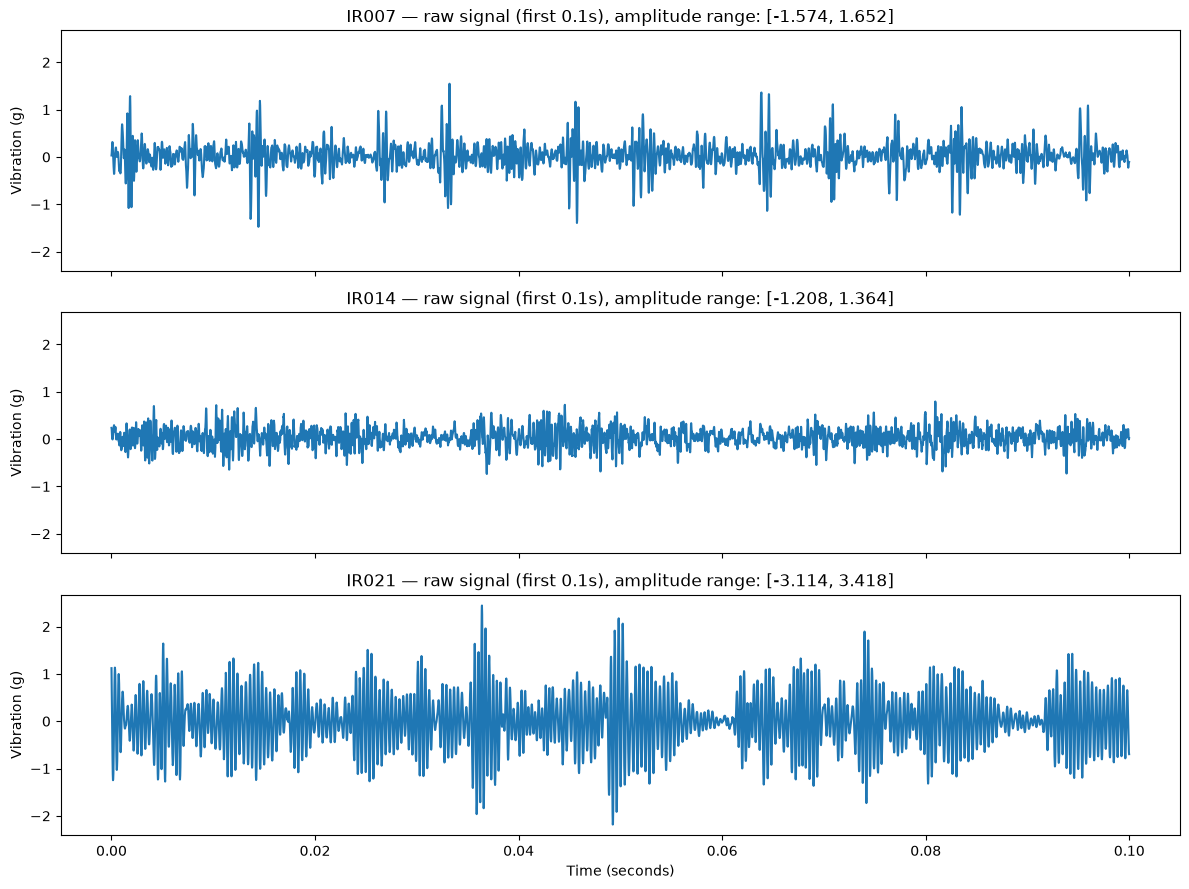

IR007 RMS: 0.2787
IR014 RMS: 0.1979
IR021 RMS: 0.6085


In [ ]:
def load_de_signal(filepath):
    signal, rpm = load_mat_file(filepath)
    return signal, rpm

sig_007, rpm_007 = load_de_signal("../data/raw/cwru/IR007_1_110.mat")
sig_014, rpm_014 = load_de_signal("../data/raw/cwru/IR014_1_175.mat")
sig_021, rpm_021 = load_de_signal("../data/raw/cwru/IR021_1_214.mat")

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True, sharey=True)
for ax, sig, label in zip(axes, [sig_007, sig_014, sig_021], ["IR007", "IR014", "IR021"]):
    n = int(0.1 * 48000)  # first 0.1 seconds, same zoom as the very first plot
    t = np.arange(n) / 48000
    ax.plot(t, sig[:n])
    ax.set_title(f"{label} — raw signal (first 0.1s), amplitude range: [{sig.min():.3f}, {sig.max():.3f}]")
    ax.set_ylabel("Vibration (g)")
axes[-1].set_xlabel("Time (seconds)")
plt.tight_layout()
plt.show()

print(f"IR007 RMS: {np.sqrt(np.mean(sig_007**2)):.4f}")
print(f"IR014 RMS: {np.sqrt(np.mean(sig_014**2)):.4f}")
print(f"IR021 RMS: {np.sqrt(np.mean(sig_021**2)):.4f}")

In [22]:
from scipy.fft import fft, fftfreq

def find_resonance_band(signal, fs=48000, search_range=(1000, 8000)):
    n = len(signal)
    yf = np.abs(fft(signal))[:n//2] / n
    xf = fftfreq(n, 1/fs)[:n//2]
    mask = (xf > search_range[0]) & (xf < search_range[1])
    peak_freq = xf[mask][np.argmax(yf[mask])]
    return peak_freq

for label, sig in [("IR007", sig_007), ("IR014", sig_014), ("IR021", sig_021)]:
    peak = find_resonance_band(sig)
    print(f"{label}: strongest resonance peak near {peak:.0f} Hz")

IR007: strongest resonance peak near 2580 Hz
IR014: strongest resonance peak near 1070 Hz
IR021: strongest resonance peak near 2586 Hz


In [ ]:
def extract_window_features_v3(window, rpm, resonance_peak, fs=48000, band_width=1000):
    freqs = compute_bearing_frequencies(rpm)

    # Adaptive band, centered on this file's own resonance peak (computed once, passed in)
    low = max(resonance_peak - band_width/2, 100)
    high = min(resonance_peak + band_width/2, fs/2 - 100)
    nyq = fs / 2
    b, a = butter(4, [low/nyq, high/nyq], btype='band')
    filtered = filtfilt(b, a, window)

    envelope = np.abs(hilbert(filtered))
    envelope = envelope - envelope.mean()
    n = len(envelope)
    yf = np.abs(fft(envelope))[:n // 2] / n
    xf = fftfreq(n, 1/fs)[:n // 2]

    rms = np.sqrt(np.mean(window**2))
    features = {}
    for name in ["BPFO", "BPFI", "BSF"]:
        for harmonic in [1, 2, 3]:
            target = freqs[name] * harmonic
            raw_energy = energy_near_frequency(xf, yf, target)
            features[f"{name}_x{harmonic}_ratio"] = raw_energy / (rms + 1e-8)

    features["rms"] = rms
    features["kurtosis"] = pd.Series(window).kurtosis()
    features["resonance_peak"] = resonance_peak  # i decided to keep this because it might itself be informative
    return features

def process_file_v3(filepath, window_size=8192):
    signal, rpm = load_mat_file(filepath)
    fault_type, severity = parse_label(filepath)

    # Find the file's resonance peak ONCE, using the full signal
    resonance_peak = find_resonance_band(signal, fs=48000, search_range=(1000, 8000))

    n_windows = len(signal) // window_size
    rows = []
    for i in range(n_windows):
        window = signal[i*window_size : (i+1)*window_size]
        feats = extract_window_features_v3(window, rpm, resonance_peak)
        feats["fault_type"] = fault_type
        feats["severity"] = severity
        feats["source_file"] = os.path.basename(filepath)
        feats["window_idx"] = i
        rows.append(feats)
    return rows

# Rebuild the full table
all_rows_v3 = []
for f in mat_files:
    all_rows_v3.extend(process_file_v3(f))

bearing_df_v3 = pd.DataFrame(all_rows_v3)
feature_cols_v3 = [c for c in bearing_df_v3.columns if c not in ["fault_type", "severity", "source_file", "window_idx"]]

print(bearing_df_v3.groupby("source_file")["resonance_peak"].first())  # confirm each file got its own real peak

# Full LOFO-CV, same test as before
lofo_results_v3 = []
for held_out_file in bearing_df_v3["source_file"].unique():
    train_lofo = bearing_df_v3[bearing_df_v3["source_file"] != held_out_file]
    test_lofo = bearing_df_v3[bearing_df_v3["source_file"] == held_out_file]
    X_tr, y_tr = train_lofo[feature_cols_v3], train_lofo["fault_type"]
    X_te, y_te = test_lofo[feature_cols_v3], test_lofo["fault_type"]
    model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc = accuracy_score(y_te, preds)
    lofo_results_v3.append({"held_out_file": held_out_file, "true_fault_type": test_lofo["fault_type"].iloc[0], "accuracy": acc})

lofo_df_v3 = pd.DataFrame(lofo_results_v3)
print(lofo_df_v3)
fault_only_v3 = lofo_df_v3[lofo_df_v3["true_fault_type"] != "Normal"]
print(f"\nMean LOFO accuracy (adaptive resonance): {fault_only_v3['accuracy'].mean():.3f}")
print(f"Min LOFO accuracy (adaptive resonance): {fault_only_v3['accuracy'].min():.3f}")

source_file
B007_0.mat               5746.873241
B007_1_123.mat           2761.715608
B007_2.mat               2880.252723
B007_3.mat               5529.895686
B014_0.mat               5747.976955
B014_1_190.mat           1059.264866
B014_2.mat               1439.319294
B014_3.mat               1439.575555
B021_0.mat               5748.620800
B021_1_227.mat           2586.634457
B021_2.mat               5619.178621
B021_3.mat               5548.830812
IR007_0.mat              2467.191688
IR007_1_110.mat          2580.242851
IR007_2.mat              5781.882492
IR007_3.mat              5690.864567
IR014_0.mat              5746.795135
IR014_1_175.mat          1069.567084
IR014_2.mat              5616.794971
IR014_3.mat              5547.366086
IR021_0.mat              1822.754962
IR021_1_214.mat          2585.627022
IR021_2.mat              2408.154556
IR021_3.mat              2374.601405
Normal_0.mat             4144.397347
Normal_1.mat             4263.135380
Normal_2.mat             4

In [ ]:
def find_best_kurtosis_band(signal, fs=48000, band_width=1000,
                              search_range=(500, 10000), step=250):
    """
    Scan candidate frequency bands, compute the KURTOSIS of each band's envelope,
    return the center frequency of the band with the highest kurtosis,
    i.e. the band where fault impacts show up most sharply, not just the loudest.
    """
    nyq = fs / 2
    best_kurtosis = -np.inf
    best_center = None

    centers = np.arange(search_range[0], search_range[1], step)
    results = []

    for center in centers:
        low = max(center - band_width/2, 100)
        high = min(center + band_width/2, nyq - 100)
        if low >= high:
            continue
        try:
            b, a = butter(4, [low/nyq, high/nyq], btype='band')
            filtered = filtfilt(b, a, signal)
            envelope = np.abs(hilbert(filtered))
            k = pd.Series(envelope).kurtosis()
            results.append({"center": center, "kurtosis": k})
            if k > best_kurtosis:
                best_kurtosis = k
                best_center = center
        except Exception:
            continue

    return best_center, best_kurtosis, pd.DataFrame(results)

# Test it on our three IR files first, before rebuilding everything
for label, sig in [("IR007", sig_007), ("IR014", sig_014), ("IR021", sig_021)]:
    center, kurt, _ = find_best_kurtosis_band(sig)
    print(f"{label}: best band center = {center} Hz, kurtosis = {kurt:.2f}")

IR007: best band center = 9500 Hz, kurtosis = 7.62
IR014: best band center = 9750 Hz, kurtosis = 10.85
IR021: best band center = 9750 Hz, kurtosis = 18.26


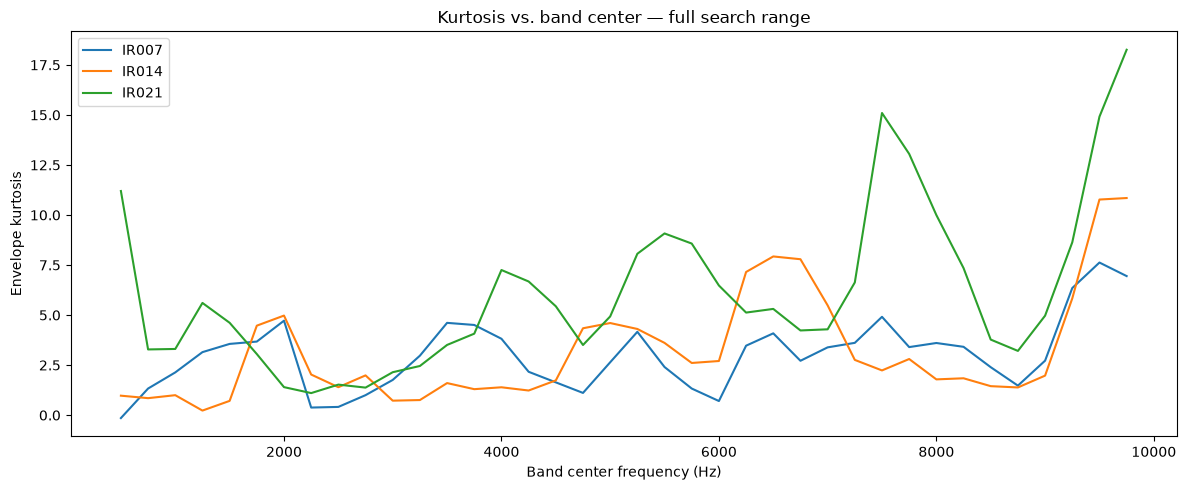

In [25]:
_, _, results_007 = find_best_kurtosis_band(sig_007)
_, _, results_014 = find_best_kurtosis_band(sig_014)
_, _, results_021 = find_best_kurtosis_band(sig_021)

plt.figure(figsize=(12, 5))
plt.plot(results_007["center"], results_007["kurtosis"], label="IR007")
plt.plot(results_014["center"], results_014["kurtosis"], label="IR014")
plt.plot(results_021["center"], results_021["kurtosis"], label="IR021")
plt.xlabel("Band center frequency (Hz)")
plt.ylabel("Envelope kurtosis")
plt.title("Kurtosis vs. band center — full search range")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from scipy.signal import find_peaks

def find_best_kurtosis_band_v2(signal, fs=48000, band_width=1000,
                                  search_range=(500, 9000), step=250):  
    nyq = fs / 2
    centers = np.arange(search_range[0], search_range[1], step)
    kurtosis_values = []

    for center in centers:
        low = max(center - band_width/2, 100)
        high = min(center + band_width/2, nyq - 100)
        if low >= high:
            kurtosis_values.append(-np.inf)
            continue
        try:
            b, a = butter(4, [low/nyq, high/nyq], btype='band')
            filtered = filtfilt(b, a, signal)
            envelope = np.abs(hilbert(filtered))
            kurtosis_values.append(pd.Series(envelope).kurtosis())
        except Exception:
            kurtosis_values.append(-np.inf)

    kurtosis_values = np.array(kurtosis_values)

    # Find genuine LOCAL peaks (rises then falls), not just the highest raw value
    peak_indices, _ = find_peaks(kurtosis_values)
    if len(peak_indices) == 0:
        # fallback: no clear local peak found, use global max as before
        best_idx = np.argmax(kurtosis_values)
    else:
        # pick the tallest genuine local peak
        best_idx = peak_indices[np.argmax(kurtosis_values[peak_indices])]

    return centers[best_idx], kurtosis_values[best_idx], pd.DataFrame({"center": centers, "kurtosis": kurtosis_values})

for label, sig in [("IR007", sig_007), ("IR014", sig_014), ("IR021", sig_021)]:
    center, kurt, _ = find_best_kurtosis_band_v2(sig)
    print(f"{label}: best REAL local peak = {center} Hz, kurtosis = {kurt:.2f}")

IR007: best REAL local peak = 7500 Hz, kurtosis = 4.91
IR014: best REAL local peak = 6500 Hz, kurtosis = 7.93
IR021: best REAL local peak = 7500 Hz, kurtosis = 15.10


In [27]:
def extract_window_features_v4(window, rpm, resonance_peak, fs=48000, band_width=1000):
    freqs = compute_bearing_frequencies(rpm)
    nyq = fs / 2
    low = max(resonance_peak - band_width/2, 100)
    high = min(resonance_peak + band_width/2, nyq - 100)
    b, a = butter(4, [low/nyq, high/nyq], btype='band')
    filtered = filtfilt(b, a, window)

    envelope = np.abs(hilbert(filtered))
    envelope = envelope - envelope.mean()
    n = len(envelope)
    yf = np.abs(fft(envelope))[:n // 2] / n
    xf = fftfreq(n, 1/fs)[:n // 2]

    rms = np.sqrt(np.mean(window**2))
    features = {}
    for name in ["BPFO", "BPFI", "BSF"]:
        for harmonic in [1, 2, 3]:
            target = freqs[name] * harmonic
            raw_energy = energy_near_frequency(xf, yf, target)
            features[f"{name}_x{harmonic}_ratio"] = raw_energy / (rms + 1e-8)

    features["rms"] = rms
    features["kurtosis"] = pd.Series(window).kurtosis()
    features["resonance_peak"] = resonance_peak
    return features

def process_file_v4(filepath, window_size=8192):
    signal, rpm = load_mat_file(filepath)
    fault_type, severity = parse_label(filepath)

    resonance_peak, _, _ = find_best_kurtosis_band_v2(signal)

    n_windows = len(signal) // window_size
    rows = []
    for i in range(n_windows):
        window = signal[i*window_size : (i+1)*window_size]
        feats = extract_window_features_v4(window, rpm, resonance_peak)
        feats["fault_type"] = fault_type
        feats["severity"] = severity
        feats["source_file"] = os.path.basename(filepath)
        feats["window_idx"] = i
        rows.append(feats)
    return rows

all_rows_v4 = []
for f in mat_files:
    all_rows_v4.extend(process_file_v4(f))

bearing_df_v4 = pd.DataFrame(all_rows_v4)
feature_cols_v4 = [c for c in bearing_df_v4.columns if c not in ["fault_type", "severity", "source_file", "window_idx"]]

print(bearing_df_v4.groupby("source_file")["resonance_peak"].first())

lofo_results_v4 = []
for held_out_file in bearing_df_v4["source_file"].unique():
    train_lofo = bearing_df_v4[bearing_df_v4["source_file"] != held_out_file]
    test_lofo = bearing_df_v4[bearing_df_v4["source_file"] == held_out_file]
    X_tr, y_tr = train_lofo[feature_cols_v4], train_lofo["fault_type"]
    X_te, y_te = test_lofo[feature_cols_v4], test_lofo["fault_type"]
    model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc = accuracy_score(y_te, preds)
    lofo_results_v4.append({"held_out_file": held_out_file, "true_fault_type": test_lofo["fault_type"].iloc[0], "accuracy": acc})

lofo_df_v4 = pd.DataFrame(lofo_results_v4)
print(lofo_df_v4)
fault_only_v4 = lofo_df_v4[lofo_df_v4["true_fault_type"] != "Normal"]
print(f"\nMean LOFO accuracy (kurtosis-based adaptive band): {fault_only_v4['accuracy'].mean():.3f}")
print(f"Min LOFO accuracy: {fault_only_v4['accuracy'].min():.3f}")

source_file
B007_0.mat               7250
B007_1_123.mat           2500
B007_2.mat               7000
B007_3.mat               4250
B014_0.mat               8250
B014_1_190.mat           1750
B014_2.mat               6500
B014_3.mat               6500
B021_0.mat               8500
B021_1_227.mat           7750
B021_2.mat               6500
B021_3.mat               4500
IR007_0.mat              8500
IR007_1_110.mat          7500
IR007_2.mat              4500
IR007_3.mat              3750
IR014_0.mat              5000
IR014_1_175.mat          6500
IR014_2.mat              6500
IR014_3.mat              6500
IR021_0.mat               750
IR021_1_214.mat          7500
IR021_2.mat              7500
IR021_3.mat              7250
Normal_0.mat             2500
Normal_1.mat             3250
Normal_2.mat             3250
Normal_3.mat             3250
OR007@6_0.mat            5000
OR007@6_2.mat            2000
OR007@6_3.mat            2000
OR007_6_1_136.mat        5250
OR014@6_0.mat            675

In [ ]:
CANDIDATE_BANDS = [1500, 3000, 5000, 7500]  
def extract_window_features_v5(window, rpm, fs=48000, band_width=1000):
    freqs = compute_bearing_frequencies(rpm)
    rms = np.sqrt(np.mean(window**2))
    features = {"rms": rms, "kurtosis": pd.Series(window).kurtosis()}

    for band_center in CANDIDATE_BANDS:
        nyq = fs / 2
        low = max(band_center - band_width/2, 100)
        high = min(band_center + band_width/2, nyq - 100)
        b, a = butter(4, [low/nyq, high/nyq], btype='band')
        filtered = filtfilt(b, a, window)
        envelope = np.abs(hilbert(filtered))
        envelope = envelope - envelope.mean()
        n = len(envelope)
        yf = np.abs(fft(envelope))[:n // 2] / n
        xf = fftfreq(n, 1/fs)[:n // 2]

        for name in ["BPFO", "BPFI", "BSF"]:
            for harmonic in [1, 2]:  # trimmed to 2 harmonics per band to control total feature count (4 bands x 3 x 2 = 24 already)
                target = freqs[name] * harmonic
                raw_energy = energy_near_frequency(xf, yf, target)
                features[f"{name}_x{harmonic}_band{band_center}"] = raw_energy / (rms + 1e-8)

    return features

In [ ]:
def process_file_v5(filepath, window_size=8192):
    signal, rpm = load_mat_file(filepath)
    fault_type, severity = parse_label(filepath)
    n_windows = len(signal) // window_size
    rows = []
    for i in range(n_windows):
        window = signal[i*window_size : (i+1)*window_size]
        feats = extract_window_features_v5(window, rpm)
        feats["fault_type"] = fault_type
        feats["severity"] = severity
        feats["source_file"] = os.path.basename(filepath)
        feats["window_idx"] = i
        rows.append(feats)
    return rows

all_rows_v5 = []
for f in mat_files:
    all_rows_v5.extend(process_file_v5(f))

bearing_df_v5 = pd.DataFrame(all_rows_v5)
feature_cols_v5 = [c for c in bearing_df_v5.columns if c not in ["fault_type", "severity", "source_file", "window_idx"]]

print(f"Total features: {len(feature_cols_v5)}")
print(bearing_df_v5.shape)

# Full LOFO-CV, same test as every previous version
lofo_results_v5 = []
for held_out_file in bearing_df_v5["source_file"].unique():
    train_lofo = bearing_df_v5[bearing_df_v5["source_file"] != held_out_file]
    test_lofo = bearing_df_v5[bearing_df_v5["source_file"] == held_out_file]
    X_tr, y_tr = train_lofo[feature_cols_v5], train_lofo["fault_type"]
    X_te, y_te = test_lofo[feature_cols_v5], test_lofo["fault_type"]
    model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc = accuracy_score(y_te, preds)
    lofo_results_v5.append({"held_out_file": held_out_file, "true_fault_type": test_lofo["fault_type"].iloc[0], "accuracy": acc})

lofo_df_v5 = pd.DataFrame(lofo_results_v5)
print(lofo_df_v5)
fault_only_v5 = lofo_df_v5[lofo_df_v5["true_fault_type"] != "Normal"]
print(f"\nMean LOFO accuracy (fixed multi-band): {fault_only_v5['accuracy'].mean():.3f}")
print(f"Min LOFO accuracy (fixed multi-band): {fault_only_v5['accuracy'].min():.3f}")

# Feature importance, which band(s) actually mattered?
model_final = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
model_final.fit(bearing_df_v5[feature_cols_v5], bearing_df_v5["fault_type"])
importances_v5 = pd.DataFrame({
    "feature": feature_cols_v5,
    "importance": model_final.feature_importances_
}).sort_values("importance", ascending=False)
print("\nTop 15 features:")
print(importances_v5.head(15))

Total features: 26
(1175, 30)
            held_out_file true_fault_type  accuracy
0              B007_0.mat               B  1.000000
1          B007_1_123.mat               B  0.779661
2              B007_2.mat               B  0.928571
3              B007_3.mat               B  1.000000
4              B014_0.mat               B  0.714286
5          B014_1_190.mat               B  0.610169
6              B014_2.mat               B  1.000000
7              B014_3.mat               B  1.000000
8              B021_0.mat               B  0.857143
9          B021_1_227.mat               B  0.593220
10             B021_2.mat               B  1.000000
11             B021_3.mat               B  1.000000
12            IR007_0.mat              IR  1.000000
13        IR007_1_110.mat              IR  1.000000
14            IR007_2.mat              IR  1.000000
15            IR007_3.mat              IR  1.000000
16            IR014_0.mat              IR  1.000000
17        IR014_1_175.mat         

In [30]:
def parse_label_v3(filename):
    name = os.path.basename(filename).replace(".mat", "")
    if "Normal" in name:
        match = re.search(r'Normal_(\d+)_', name)
        load = match.group(1) if match else None
        return "Normal", None, None, load

    match_or = re.match(r'(OR)(\d+)_(\d+)_(\d+)_(\d+)', name)
    if match_or:
        fault_type, severity, position, load, fileid = match_or.groups()
        return fault_type, severity, position, load

    match_std = re.match(r'([A-Za-z]+)(\d+)_(\d+)_(\d+)', name)
    if match_std:
        fault_type, severity, load, fileid = match_std.groups()
        return fault_type, severity, None, load

    return "Unknown", None, None, None

In [31]:
data_dir = "../data/raw/cwru"
mat_files_all = glob.glob(os.path.join(data_dir, "*.mat"))
print(f"Total files found: {len(mat_files_all)}")

summary_v2 = []
for f in mat_files_all:
    try:
        signal, rpm = load_mat_file(f)
        fault_type, severity, position, load = parse_label_v3(f)
        summary_v2.append({
            "file": os.path.basename(f),
            "fault_type": fault_type,
            "severity": severity,
            "position": position,
            "load": load,
            "rpm": rpm,
            "n_samples": len(signal)
        })
    except Exception as e:
        print(f"FAILED to load {f}: {e}")

summary_df_v2 = pd.DataFrame(summary_v2)
print(summary_df_v2)
print()
print("Coverage check — count per (fault_type, severity, load):")
print(summary_df_v2.groupby(["fault_type", "severity", "load"]).size())

Total files found: 41
                     file fault_type severity position load   rpm  n_samples
0              B007_0.mat    Unknown      NaN      NaN  NaN  1796     122571
1          B007_1_123.mat          B      007      NaN    1  1772     487384
2              B007_2.mat    Unknown      NaN      NaN  NaN  1748     121556
3              B007_3.mat    Unknown      NaN      NaN  NaN  1722     121556
4              B014_0.mat    Unknown      NaN      NaN  NaN  1796     121846
5          B014_1_190.mat          B      014      NaN    1  1772     486224
6              B014_2.mat    Unknown      NaN      NaN  NaN  1749     121991
7              B014_3.mat    Unknown      NaN      NaN  NaN  1724     122136
8              B021_0.mat    Unknown      NaN      NaN  NaN  1796     121991
9          B021_1_227.mat          B      021      NaN    1  1774     486804
10             B021_2.mat    Unknown      NaN      NaN  NaN  1754     122136
11             B021_3.mat    Unknown      NaN      NaN

In [32]:
def parse_label_v4(filename):
    name = os.path.basename(filename).replace(".mat", "")
    if "Normal" in name:
        match = re.search(r'Normal_(\d+)', name)
        load = match.group(1) if match else None
        return "Normal", None, None, load
    match_or = re.match(r'OR(\d+)[@_](\d+)_(\d+)(?:_(\d+))?$', name)
    if match_or:
        severity, position, load, fileid = match_or.groups()
        return "OR", severity, position, load
    match_std = re.match(r'([A-Za-z]+)(\d+)_(\d+)(?:_(\d+))?$', name)
    if match_std:
        fault_type, severity, load, fileid = match_std.groups()
        return fault_type, severity, None, load
    return "Unknown", None, None, None

# Check: are Normal_1.mat and Time_Normal_1_098.mat actually duplicates?
sig_a, rpm_a = load_mat_file("../data/raw/cwru/Normal_1.mat")
sig_b, rpm_b = load_mat_file("../data/raw/cwru/Time_Normal_1_098.mat")
print(f"Normal_1: {len(sig_a)} samples, RPM {rpm_a}")
print(f"Time_Normal_1_098: {len(sig_b)} samples, RPM {rpm_b}")
print(f"Same length: {len(sig_a) == len(sig_b)}")
if len(sig_a) == len(sig_b):
    print(f"Identical values: {(sig_a == sig_b).all()}")

Normal_1: 483903 samples, RPM 1772
Time_Normal_1_098: 483903 samples, RPM 1772
Same length: True
Identical values: True


In [ ]:
# Exclude the duplicate before processing
data_dir = "../data/raw/cwru"
mat_files_all = [f for f in glob.glob(os.path.join(data_dir, "*.mat")) 
                  if "Time_Normal" not in f]
print(f"Total files after removing duplicate: {len(mat_files_all)}")

def process_file_v7(filepath, window_size=8192):
    signal, rpm = load_mat_file(filepath)
    fault_type, severity, position, load = parse_label_v4(filepath)
    n_windows = len(signal) // window_size
    rows = []
    for i in range(n_windows):
        window = signal[i*window_size : (i+1)*window_size]
        feats = extract_window_features_v2(window, rpm)  # the best validated feature approach (RMS-normalized ratios, fixed band)
        feats["fault_type"] = fault_type
        feats["severity"] = severity
        feats["position"] = position
        feats["load"] = load
        feats["source_file"] = os.path.basename(filepath)
        feats["window_idx"] = i
        rows.append(feats)
    return rows

all_rows_v7 = []
for f in mat_files_all:
    all_rows_v7.extend(process_file_v7(f))

bearing_df_v7 = pd.DataFrame(all_rows_v7)
feature_cols_v7 = [c for c in bearing_df_v7.columns if c not in ["fault_type", "severity", "position", "load", "source_file", "window_idx"]]

print(bearing_df_v7.shape)
print(bearing_df_v7.groupby(["fault_type", "severity"])["load"].nunique())  # confirm 4 loads per condition now

# The real test: LOFO by FILE, now with far more files to draw on
lofo_results_v7 = []
for held_out_file in bearing_df_v7["source_file"].unique():
    train_lofo = bearing_df_v7[bearing_df_v7["source_file"] != held_out_file]
    test_lofo = bearing_df_v7[bearing_df_v7["source_file"] == held_out_file]
    X_tr, y_tr = train_lofo[feature_cols_v7], train_lofo["fault_type"]
    X_te, y_te = test_lofo[feature_cols_v7], test_lofo["fault_type"]
    model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc = accuracy_score(y_te, preds)
    lofo_results_v7.append({"held_out_file": held_out_file, "true_fault_type": test_lofo["fault_type"].iloc[0], "accuracy": acc})

lofo_df_v7 = pd.DataFrame(lofo_results_v7)
fault_only_v7 = lofo_df_v7[lofo_df_v7["true_fault_type"] != "Normal"]
print(f"\nMean LOFO accuracy (multi-load): {fault_only_v7['accuracy'].mean():.3f}")
print(f"Min LOFO accuracy: {fault_only_v7['accuracy'].min():.3f}")
print(lofo_df_v7.sort_values("accuracy"))

Total files after removing duplicate: 40
(1116, 17)
fault_type  severity
B           007         4
            014         4
            021         4
IR          007         4
            014         4
            021         4
OR          007         4
            014         4
            021         4
Name: load, dtype: int64

Mean LOFO accuracy (multi-load): 0.700
Min LOFO accuracy: 0.000
        held_out_file true_fault_type  accuracy
18        IR014_2.mat              IR  0.000000
17    IR014_1_175.mat              IR  0.000000
35  OR014_6_1_202.mat              OR  0.000000
1      B007_1_123.mat               B  0.067797
19        IR014_3.mat              IR  0.071429
21    IR021_1_214.mat              IR  0.135593
32      OR014@6_0.mat              OR  0.142857
4          B014_0.mat               B  0.285714
34      OR014@6_3.mat              OR  0.285714
33      OR014@6_2.mat              OR  0.285714
20        IR021_0.mat              IR  0.571429
37      OR021@6_2.mat      

In [34]:
from sklearn.metrics import accuracy_score

# Retrain on everything except one held-out file, but this time capture PROBABILITIES not just hard predictions
def evaluate_with_confidence(held_out_file, threshold=0.6):
    train_lofo = bearing_df_v7[bearing_df_v7["source_file"] != held_out_file]
    test_lofo = bearing_df_v7[bearing_df_v7["source_file"] == held_out_file]
    X_tr, y_tr = train_lofo[feature_cols_v7], train_lofo["fault_type"]
    X_te, y_te = test_lofo[feature_cols_v7], test_lofo["fault_type"]

    model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
    model.fit(X_tr, y_tr)

    probs = model.predict_proba(X_te)
    preds = model.classes_[np.argmax(probs, axis=1)]
    confidences = np.max(probs, axis=1)

    # Split into confident vs. flagged-for-review
    confident_mask = confidences >= threshold
    n_flagged = (~confident_mask).sum()
    n_total = len(y_te)

    if confident_mask.sum() > 0:
        acc_on_confident = accuracy_score(y_te[confident_mask], preds[confident_mask])
    else:
        acc_on_confident = None

    return {
        "held_out_file": held_out_file,
        "true_fault_type": test_lofo["fault_type"].iloc[0],
        "overall_accuracy": accuracy_score(y_te, preds),
        "pct_flagged_for_review": n_flagged / n_total,
        "accuracy_on_confident_only": acc_on_confident
    }

confidence_results = [evaluate_with_confidence(f) for f in bearing_df_v7["source_file"].unique()]
confidence_df = pd.DataFrame(confidence_results)
print(confidence_df.sort_values("overall_accuracy"))

# The key production number: accuracy on what the system CHOSE to answer, not everything it was forced to guess on
fault_only_conf = confidence_df[confidence_df["true_fault_type"] != "Normal"]
print(f"\nOverall LOFO accuracy (forced answer, no threshold): {fault_only_conf['overall_accuracy'].mean():.3f}")
print(f"Accuracy on CONFIDENT predictions only: {fault_only_conf['accuracy_on_confident_only'].mean():.3f}")
print(f"Average % of windows flagged for human review: {fault_only_conf['pct_flagged_for_review'].mean():.3f}")

        held_out_file true_fault_type  overall_accuracy  \
18        IR014_2.mat              IR          0.000000   
17    IR014_1_175.mat              IR          0.000000   
35  OR014_6_1_202.mat              OR          0.000000   
1      B007_1_123.mat               B          0.067797   
19        IR014_3.mat              IR          0.071429   
21    IR021_1_214.mat              IR          0.135593   
32      OR014@6_0.mat              OR          0.142857   
4          B014_0.mat               B          0.285714   
34      OR014@6_3.mat              OR          0.285714   
33      OR014@6_2.mat              OR          0.285714   
20        IR021_0.mat              IR          0.571429   
37      OR021@6_2.mat              OR          0.642857   
38      OR021@6_3.mat              OR          0.642857   
6          B014_2.mat               B          0.714286   
5      B014_1_190.mat               B          0.847458   
10         B021_2.mat               B          0.857143 

In [35]:
from sklearn.calibration import CalibratedClassifierCV

def evaluate_with_calibration(held_out_file, threshold=0.6):
    train_lofo = bearing_df_v7[bearing_df_v7["source_file"] != held_out_file]
    test_lofo = bearing_df_v7[bearing_df_v7["source_file"] == held_out_file]
    X_tr, y_tr = train_lofo[feature_cols_v7], train_lofo["fault_type"]
    X_te, y_te = test_lofo[feature_cols_v7], test_lofo["fault_type"]

    base_model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
    # Platt scaling (sigmoid), calibrated using 5-fold CV on the TRAINING data only
    # never touches the held-out test file - stays a fair, honest evaluation
    calibrated_model = CalibratedClassifierCV(base_model, method='sigmoid', cv=5)
    calibrated_model.fit(X_tr, y_tr)

    probs = calibrated_model.predict_proba(X_te)
    preds = calibrated_model.classes_[np.argmax(probs, axis=1)]
    confidences = np.max(probs, axis=1)

    confident_mask = confidences >= threshold
    n_flagged = (~confident_mask).sum()
    n_total = len(y_te)

    acc_on_confident = accuracy_score(y_te[confident_mask], preds[confident_mask]) if confident_mask.sum() > 0 else None

    return {
        "held_out_file": held_out_file,
        "true_fault_type": test_lofo["fault_type"].iloc[0],
        "overall_accuracy": accuracy_score(y_te, preds),
        "pct_flagged_for_review": n_flagged / n_total,
        "accuracy_on_confident_only": acc_on_confident
    }

calibration_results = [evaluate_with_calibration(f) for f in bearing_df_v7["source_file"].unique()]
calibration_df = pd.DataFrame(calibration_results)

fault_only_cal = calibration_df[calibration_df["true_fault_type"] != "Normal"]
print(f"Overall LOFO accuracy (calibrated, forced answer): {fault_only_cal['overall_accuracy'].mean():.3f}")
print(f"Accuracy on CONFIDENT predictions only (calibrated): {fault_only_cal['accuracy_on_confident_only'].mean():.3f}")
print(f"Average % flagged for review (calibrated): {fault_only_cal['pct_flagged_for_review'].mean():.3f}")
print()
print(calibration_df.sort_values("overall_accuracy"))

Overall LOFO accuracy (calibrated, forced answer): 0.681
Accuracy on CONFIDENT predictions only (calibrated): 0.710
Average % flagged for review (calibrated): 0.299

        held_out_file true_fault_type  overall_accuracy  \
1      B007_1_123.mat               B          0.000000   
21    IR021_1_214.mat              IR          0.000000   
18        IR014_2.mat              IR          0.000000   
17    IR014_1_175.mat              IR          0.000000   
39  OR021_6_1_239.mat              OR          0.000000   
35  OR014_6_1_202.mat              OR          0.000000   
19        IR014_3.mat              IR          0.071429   
32      OR014@6_0.mat              OR          0.142857   
34      OR014@6_3.mat              OR          0.285714   
4          B014_0.mat               B          0.285714   
5      B014_1_190.mat               B          0.694915   
37      OR021@6_2.mat              OR          0.714286   
10         B021_2.mat               B          0.714286   
6       

In [36]:
# Rebuild the exact held-out scenario for B007_1_123.mat specifically
held_out = "B007_1_123.mat"
train_check = bearing_df_v7[bearing_df_v7["source_file"] != held_out]
test_check = bearing_df_v7[bearing_df_v7["source_file"] == held_out]

model_check = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
model_check.fit(train_check[feature_cols_v7], train_check["fault_type"])
preds_check = model_check.predict(test_check[feature_cols_v7])

print("B007_1_123 windows got predicted as:")
print(pd.Series(preds_check).value_counts())

B007_1_123 windows got predicted as:
OR    55
B      4
Name: count, dtype: int64


In [37]:
b007_check = bearing_df_v7[(bearing_df_v7["fault_type"]=="B") & (bearing_df_v7["severity"]=="007")]
print(b007_check.groupby("load")[["BPFO_x1_ratio", "BPFI_x1_ratio", "BSF_x1_ratio", "rms", "kurtosis"]].mean())

      BPFO_x1_ratio  BPFI_x1_ratio  BSF_x1_ratio       rms  kurtosis
load                                                                
0          0.008503       0.010430      0.006100  0.138872 -0.036685
1          0.055781       0.071679      0.088951  0.141199  0.049039
2          0.004529       0.013065      0.006864  0.147192 -0.169924
3          0.011082       0.005568      0.007397  0.153831 -0.103796


In [38]:
for load_label, fname in [("0", "B007_0.mat"), ("1", "B007_1_123.mat"), ("2", "B007_2.mat"), ("3", "B007_3.mat")]:
    sig, rpm = load_mat_file(f"../data/raw/cwru/{fname}")
    peak = find_resonance_band(sig, fs=48000, search_range=(1000, 8000))
    rms_val = np.sqrt(np.mean(sig**2))
    print(f"Load {load_label} ({fname}): RPM={rpm}, resonance peak={peak:.0f} Hz, RMS={rms_val:.4f}")

Load 0 (B007_0.mat): RPM=1796, resonance peak=5747 Hz, RMS=0.1392
Load 1 (B007_1_123.mat): RPM=1772, resonance peak=2762 Hz, RMS=0.1414
Load 2 (B007_2.mat): RPM=1748, resonance peak=2880 Hz, RMS=0.1473
Load 3 (B007_3.mat): RPM=1722, resonance peak=5530 Hz, RMS=0.1536


In [39]:
CANDIDATE_BANDS_V2 = [2800, 5600]  # informed by the real clusters we just found, not a guess

def extract_window_features_v6(window, rpm, fs=48000, band_width=1200):
    freqs = compute_bearing_frequencies(rpm)
    rms = np.sqrt(np.mean(window**2))
    features = {"rms": rms, "kurtosis": pd.Series(window).kurtosis()}

    for band_center in CANDIDATE_BANDS_V2:
        nyq = fs / 2
        low = max(band_center - band_width/2, 100)
        high = min(band_center + band_width/2, nyq - 100)
        b, a = butter(4, [low/nyq, high/nyq], btype='band')
        filtered = filtfilt(b, a, window)
        envelope = np.abs(hilbert(filtered))
        envelope = envelope - envelope.mean()
        n = len(envelope)
        yf = np.abs(fft(envelope))[:n // 2] / n
        xf = fftfreq(n, 1/fs)[:n // 2]
        for name in ["BPFO", "BPFI", "BSF"]:
            for harmonic in [1, 2]:
                target = freqs[name] * harmonic
                raw_energy = energy_near_frequency(xf, yf, target)
                features[f"{name}_x{harmonic}_band{band_center}"] = raw_energy / (rms + 1e-8)

    return features

In [40]:
def process_file_v8(filepath, window_size=8192):
    signal, rpm = load_mat_file(filepath)
    fault_type, severity, position, load = parse_label_v4(filepath)
    n_windows = len(signal) // window_size
    rows = []
    for i in range(n_windows):
        window = signal[i*window_size : (i+1)*window_size]
        feats = extract_window_features_v6(window, rpm)
        feats["fault_type"] = fault_type
        feats["severity"] = severity
        feats["position"] = position
        feats["load"] = load
        feats["source_file"] = os.path.basename(filepath)
        feats["window_idx"] = i
        rows.append(feats)
    return rows

all_rows_v8 = []
for f in mat_files_all:
    all_rows_v8.extend(process_file_v8(f))

bearing_df_v8 = pd.DataFrame(all_rows_v8)
feature_cols_v8 = [c for c in bearing_df_v8.columns if c not in ["fault_type", "severity", "position", "load", "source_file", "window_idx"]]

print(f"Total features: {len(feature_cols_v8)}")
print(bearing_df_v8.shape)

# Full LOFO-CV, same test as every prior version
lofo_results_v8 = []
for held_out_file in bearing_df_v8["source_file"].unique():
    train_lofo = bearing_df_v8[bearing_df_v8["source_file"] != held_out_file]
    test_lofo = bearing_df_v8[bearing_df_v8["source_file"] == held_out_file]
    X_tr, y_tr = train_lofo[feature_cols_v8], train_lofo["fault_type"]
    X_te, y_te = test_lofo[feature_cols_v8], test_lofo["fault_type"]
    model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc = accuracy_score(y_te, preds)
    lofo_results_v8.append({"held_out_file": held_out_file, "true_fault_type": test_lofo["fault_type"].iloc[0], "accuracy": acc})

lofo_df_v8 = pd.DataFrame(lofo_results_v8)
fault_only_v8 = lofo_df_v8[lofo_df_v8["true_fault_type"] != "Normal"]
print(f"\nMean LOFO accuracy (two-band, evidence-based): {fault_only_v8['accuracy'].mean():.3f}")
print(f"Min LOFO accuracy: {fault_only_v8['accuracy'].min():.3f}")
print(lofo_df_v8.sort_values("accuracy"))

# Specifically check our two diagnosed problem files
print("\nB007_1_123 and IR014 files specifically:")
print(lofo_df_v8[lofo_df_v8["held_out_file"].str.contains("B007_1|IR014")])

Total features: 14
(1116, 20)

Mean LOFO accuracy (two-band, evidence-based): 0.654
Min LOFO accuracy: 0.000
        held_out_file true_fault_type  accuracy
18        IR014_2.mat              IR  0.000000
21    IR021_1_214.mat              IR  0.000000
17    IR014_1_175.mat              IR  0.000000
32      OR014@6_0.mat              OR  0.000000
35  OR014_6_1_202.mat              OR  0.000000
34      OR014@6_3.mat              OR  0.000000
33      OR014@6_2.mat              OR  0.000000
20        IR021_0.mat              IR  0.071429
19        IR014_3.mat              IR  0.142857
39  OR021_6_1_239.mat              OR  0.220339
1      B007_1_123.mat               B  0.389831
37      OR021@6_2.mat              OR  0.642857
7          B014_3.mat               B  0.642857
38      OR021@6_3.mat              OR  0.642857
4          B014_0.mat               B  0.714286
6          B014_2.mat               B  0.785714
30      OR007@6_3.mat              OR  0.857143
8          B021_0.mat      

In [41]:
from xgboost import XGBClassifier

def lofo_test(model_class, model_params, feature_cols, label="model"):
    results = []
    for held_out_file in bearing_df_v7["source_file"].unique():
        train_lofo = bearing_df_v7[bearing_df_v7["source_file"] != held_out_file]
        test_lofo = bearing_df_v7[bearing_df_v7["source_file"] == held_out_file]
        X_tr, y_tr = train_lofo[feature_cols], train_lofo["fault_type"]
        X_te, y_te = test_lofo[feature_cols], test_lofo["fault_type"]

        model = model_class(**model_params)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_te)
        acc = accuracy_score(y_te, preds)
        results.append({"held_out_file": held_out_file, "true_fault_type": test_lofo["fault_type"].iloc[0], "accuracy": acc})

    df = pd.DataFrame(results)
    fault_only = df[df["true_fault_type"] != "Normal"]
    print(f"{label}: mean LOFO = {fault_only['accuracy'].mean():.3f}, min = {fault_only['accuracy'].min():.3f}")
    return df

# XGBoost needs numeric labels, not strings
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
bearing_df_v7["fault_type_encoded"] = le.fit_transform(bearing_df_v7["fault_type"])

def lofo_test_xgb(feature_cols):
    results = []
    for held_out_file in bearing_df_v7["source_file"].unique():
        train_lofo = bearing_df_v7[bearing_df_v7["source_file"] != held_out_file]
        test_lofo = bearing_df_v7[bearing_df_v7["source_file"] == held_out_file]
        X_tr, y_tr = train_lofo[feature_cols], train_lofo["fault_type_encoded"]
        X_te, y_te = test_lofo[feature_cols], test_lofo["fault_type_encoded"]

        model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42, eval_metric='mlogloss')
        model.fit(X_tr, y_tr)
        preds = model.predict(X_te)
        acc = accuracy_score(y_te, preds)
        results.append({"held_out_file": held_out_file, "true_fault_type": le.inverse_transform([test_lofo["fault_type_encoded"].iloc[0]])[0], "accuracy": acc})

    df = pd.DataFrame(results)
    fault_only = df[df["true_fault_type"] != "Normal"]
    print(f"XGBoost: mean LOFO = {fault_only['accuracy'].mean():.3f}, min = {fault_only['accuracy'].min():.3f}")
    return df

# Re-confirm RandomForest baseline for a fair side-by-side
rf_results = lofo_test(RandomForestClassifier, {"n_estimators": 200, "max_depth": 6, "random_state": 42}, feature_cols_v7, "RandomForest")
xgb_results = lofo_test_xgb(feature_cols_v7)

RandomForest: mean LOFO = 0.700, min = 0.000
XGBoost: mean LOFO = 0.633, min = 0.000


In [42]:
def get_typical_resonance(fault_type, mat_files_all):
    peaks = []
    for f in mat_files_all:
        _, sev, _, _ = parse_label_v4(f)
        ft, _, _, _ = parse_label_v4(f)
        if ft == fault_type:
            sig, rpm = load_mat_file(f)
            peak = find_resonance_band(sig, fs=48000, search_range=(1000, 8000))
            peaks.append(peak)
    return np.median(peaks), peaks

for ft in ["B", "IR", "OR"]:
    median_peak, all_peaks = get_typical_resonance(ft, mat_files_all)
    print(f"{ft}: median resonance = {median_peak:.0f} Hz, all peaks = {[f'{p:.0f}' for p in all_peaks]}")

B: median resonance = 4205 Hz, all peaks = ['5747', '2762', '2880', '5530', '5748', '1059', '1439', '1440', '5749', '2587', '5619', '5549']
IR: median resonance = 2583 Hz, all peaks = ['2467', '2580', '5782', '5691', '5747', '1070', '5617', '5547', '1823', '2586', '2408', '2375']
OR: median resonance = 2879 Hz, all peaks = ['2754', '2880', '2880', '3401', '5747', '2880', '2879', '3370', '2150', '2278', '2243', '2803']


In [43]:
load_resonance = []
for f in mat_files_all:
    ft, sev, pos, load = parse_label_v4(f)
    sig, rpm = load_mat_file(f)
    peak = find_resonance_band(sig, fs=48000, search_range=(1000, 8000))
    load_resonance.append({"file": os.path.basename(f), "fault_type": ft, "load": load, "rpm": rpm, "resonance_peak": peak})

load_res_df = pd.DataFrame(load_resonance)
print(load_res_df.groupby("load")["resonance_peak"].agg(["mean", "median", "std", "count"]))
print()
print(load_res_df.sort_values(["load", "fault_type"]))

             mean       median          std  count
load                                              
0     4207.505137  4945.596241  1729.584217     10
1     2648.120458  2674.175032   986.748934     10
2     3604.647768  2880.205432  1589.434223     10
3     3839.395439  3570.499909  1653.234559     10

                 file fault_type load   rpm  resonance_peak
0          B007_0.mat          B    0  1796     5746.873241
4          B014_0.mat          B    0  1796     5747.976955
8          B021_0.mat          B    0  1796     5748.620800
12        IR007_0.mat         IR    0  1797     2467.191688
16        IR014_0.mat         IR    0  1796     5746.795135
20        IR021_0.mat         IR    0  1797     1822.754962
24       Normal_0.mat     Normal    0  1796     4144.397347
28      OR007@6_0.mat         OR    0  1796     2753.514604
32      OR014@6_0.mat         OR    0  1796     5746.795135
36      OR021@6_0.mat         OR    0  1796     2150.131508
1      B007_1_123.mat          B 

In [44]:
# Train the ACTUAL final, deployable Bearing model on ALL available data
# (not a LOFO fold - this is for real predictions, not evaluation)
from sklearn.ensemble import RandomForestClassifier
bearing_final_model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
bearing_final_model.fit(bearing_df_v7[feature_cols_v7], bearing_df_v7["fault_type"])

print("Trained final Bearing model on all", len(bearing_df_v7), "rows")

import joblib
import os

os.makedirs("../models/bearing", exist_ok=True)
joblib.dump(bearing_final_model, "../models/bearing/final_model.pkl")
joblib.dump(feature_cols_v7, "../models/bearing/feature_names.pkl")

print("Saved bearing model and feature names to ../models/bearing/")
print(f"Number of features: {len(feature_cols_v7)}")

Trained final Bearing model on all 1116 rows
Saved bearing model and feature names to ../models/bearing/
Number of features: 11


In [45]:
import json

sample_row_bearing = bearing_df_v7[feature_cols_v7].iloc[50].tolist()
true_label = bearing_df_v7["fault_type"].iloc[50]
print("True label for this row:", true_label)
print(json.dumps({"features": sample_row_bearing}))

True label for this row: B
{"features": [0.016581954812667946, 0.056542496167476385, 0.05001466055131273, 0.10577094082149173, 0.05001466055131273, 0.041540921336774714, 0.099906043448636, 0.08716150317583952, 0.056542496167476385, 0.1451889544368352, 0.21823608777010461]}


In [46]:
import os
os.makedirs("../dashboard/sample_data", exist_ok=True)

sample_export = bearing_df_v7[feature_cols_v7].sample(10, random_state=1)
sample_export["true_fault_type"] = bearing_df_v7.loc[sample_export.index, "fault_type"]
sample_export.to_csv("../dashboard/sample_data/bearing_samples.csv", index=False)
print("Saved 10 bearing samples")

Saved 10 bearing samples


In [47]:
# Stream through one real file's windows, in order
live_file = bearing_df_v7[bearing_df_v7["source_file"] == "IR021_1_214.mat"].sort_values("window_idx")
live_export = live_file[feature_cols_v7 + ["window_idx", "fault_type"]].copy()
live_export.to_csv("../dashboard/sample_data/bearing_live_feed.csv", index=False)
print(f"Exported {len(live_export)} windows, true fault: {live_file['fault_type'].iloc[0]}")

Exported 59 windows, true fault: IR
